# Getting Started - Reading Data

# Introduction

Welcome to the [dClimate](https://www.dclimate.net/) Getting Started Jupyter notebook. This notebook should give you all the tools you need to begin your decentralized GIS journey. To learn more about our architecture decisions in-depth please read https://blog.dclimate.net/introducing-zarrchitecture-on-dclimate/

Let's first define some things to ensure we are all on the same page. If you are new to [DeSci](https://ethereum.org/en/desci/?ref=blog.dclimate.net) (Decentralized Science - we'll get back to this later) I would suggest for you to stick around. 

# Background

## What is decentralization? 

To summarize, decentralization is the process by which our modes of communication and access shift from relying on central authorities or gatekeepers. (e.g., a single institution or platform) to a model where ownership, control, and decision-making are distributed across many independent participants or nodes in a network. In simpler terms, instead of relying on servers where we're a client trying to access from an API, we are all client-servers, able to not only get information but also share information with peers. 

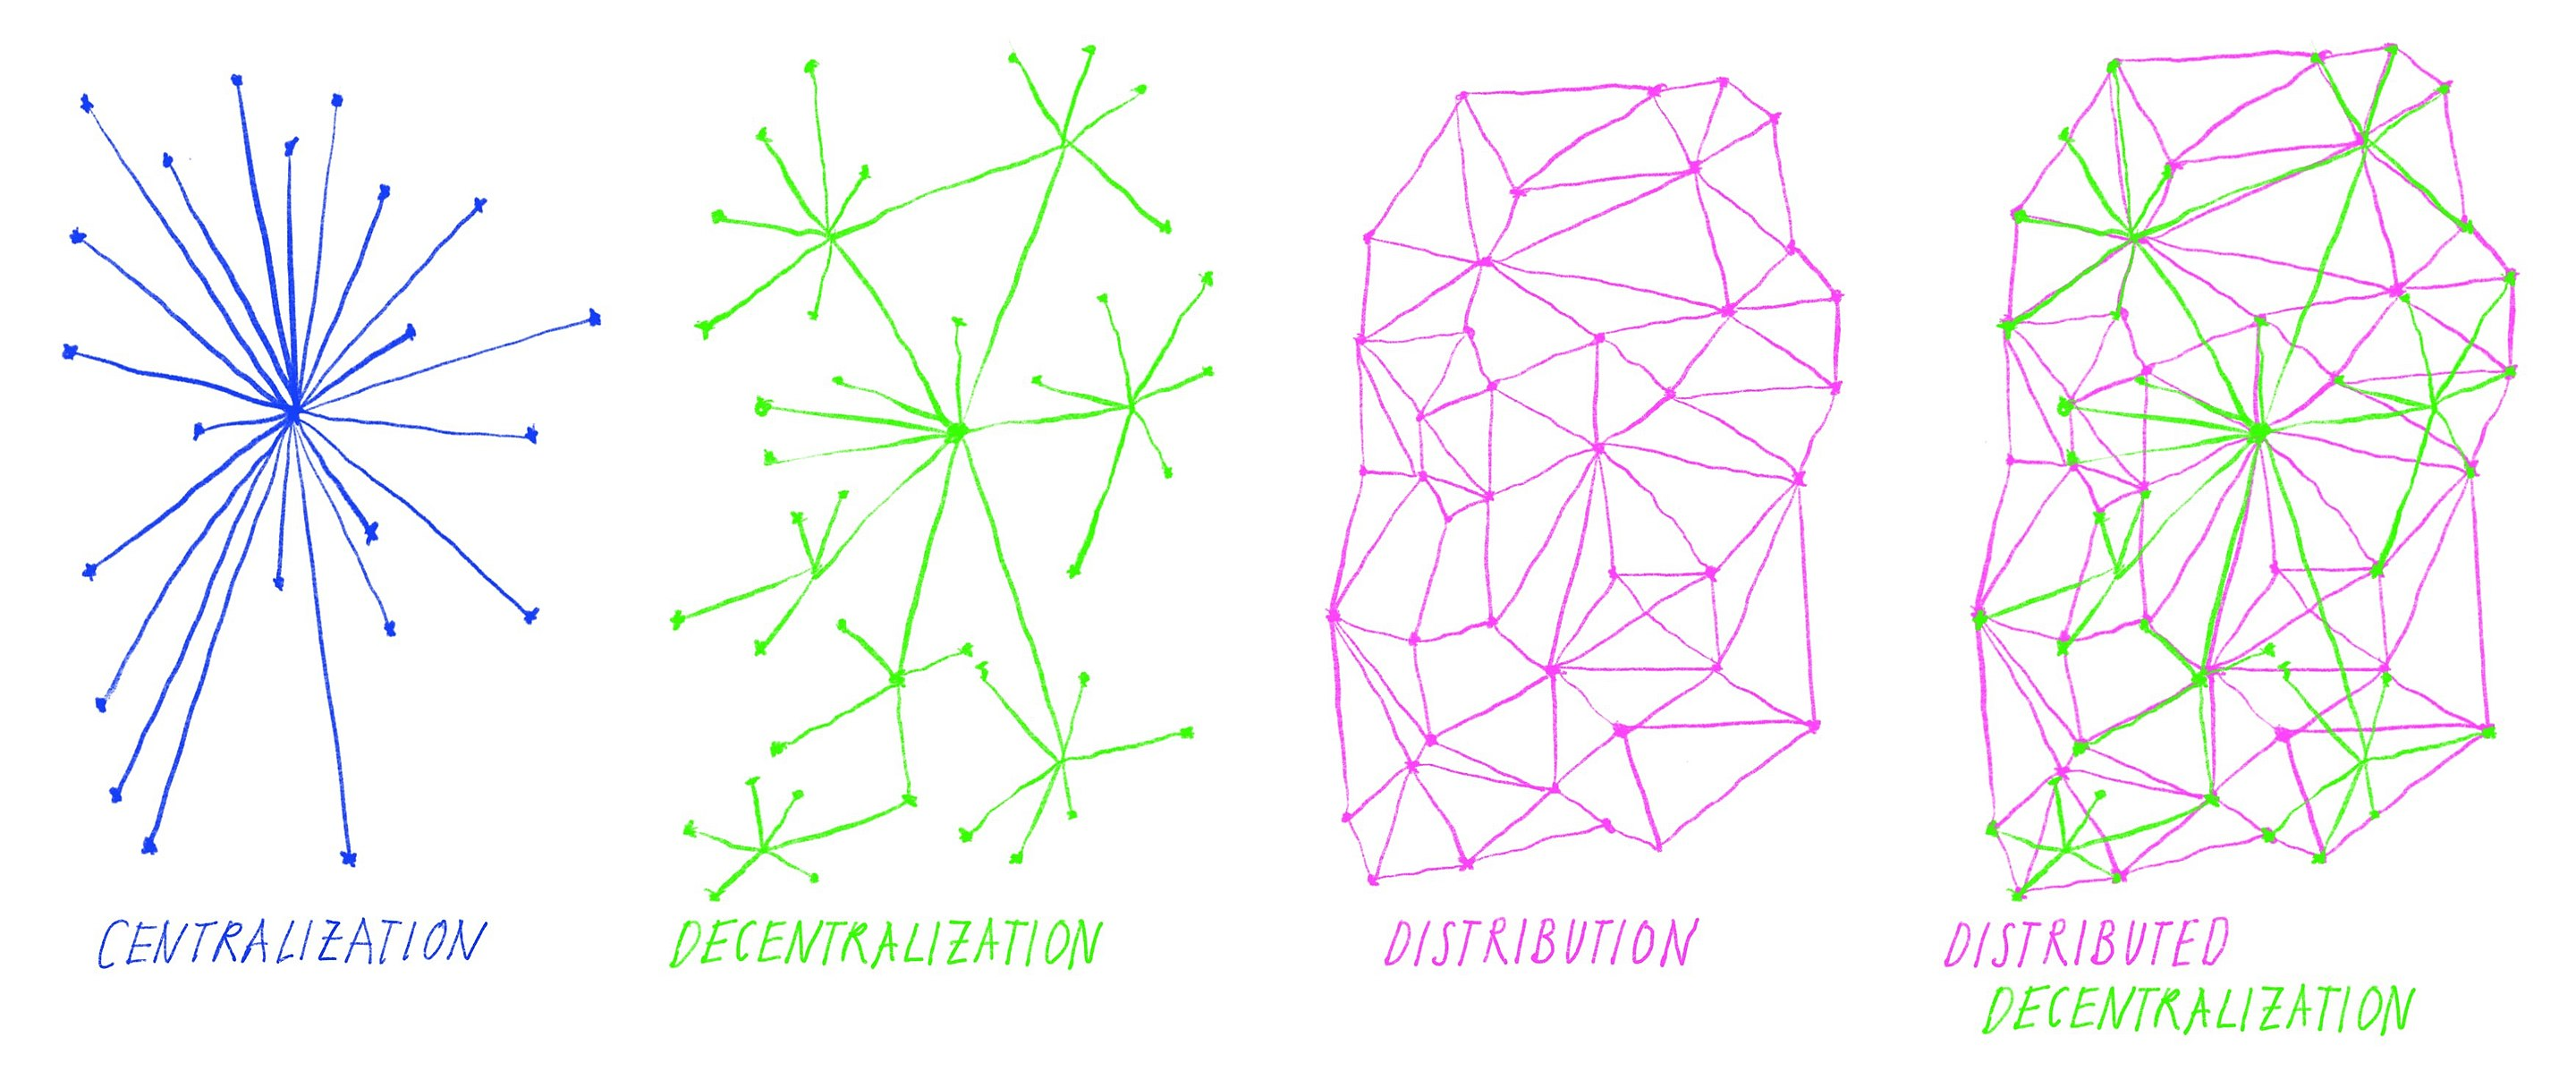

This model may be familiar to those of you who have used P2P ([peer-to-peer](https://en.wikipedia.org/wiki/Peer-to-peer)) software such as [Bittorrent](https://en.wikipedia.org/wiki/BitTorrent). Instead of downloading from a central server, many different actors share data through the network.

## Why is decentralization important?

In the context of data sharing, decentralization has many advantages:
 
- In a decentralized model, data is stored by a peer-to-peer network of nodes that each hold part or the entirety of a dataset. No single node has the power to alter or delete data without network consensus, enhancing data **integrity** and reducing single points of failure. Additionally, unlike in traditional systems where you access data from one location via a url, in decentralized storage systems such as [IPFS](https://docs.ipfs.tech/), which dClimate uses, content is asked for via [hash](https://fleek.xyz/blog/learn/understanding-content-identifiers-ipfs-onchain-hosting-and-storage/#:~:text=What%20is%20content%20addressing%20in,location%20of%20those%20devices%20changes.). In other words you tell the network you want this "hash" and all the nodes gossip to get you the data you are looking for. This results in increased **data availability**.
- Decentralized systems rely on cryptographic proofs, consensus mechanisms, and transparent logs of transactions or validations to build trust. Peer review or data validation can occur openly, making any manipulations or errors easier to detect. **Reproducibility** is very important in citizen science. Oftentimes it is very difficult to replicate findings in a study because data is hard to get as a result of centralization. Decentralized technologies allow us to replicate data across various sources with strict data integrity (in other words you don't have to worry someone else hosting the data can change that data).
- A decentralized network remains **resilient** because the data and governance rules are replicated across many nodes. No single point of failure or censorship can prevent the system from functioning. In traditional centralized networks, if an API goes down, data is inaccessible, which many of us have seen before. Decentralized networks ensure that as long as data is replicated somewhere in the network it will be accessible.

You may hear about decentralization in the context of blockchain but we don't have to worry about that for now. Just know that blockchains use many of these same concepts for building permissionless applications.

## How does decentralization work in the context of GIS?

Traditional GIS software normally relies on retrieving data from APIs or cloud services (e.g. buckets) such as Amazon S3. In the case of APIs, you normally have to deal with tokens, rate limiting, and the API uptime. These APIs often go down or are unavailable during maintenance. In the case of Amazon S3, you normally have to pay data bandwidth fees (egress), which for GIS analysis can be significant. It becomes very difficult for multiple people or organizations to share data between each other to reduce the load of storing and sharing the data.

What if there was a better way? There are peer to peer filesharing platforms such as [BitTorrent](https://en.wikipedia.org/wiki/BitTorrent), but what if there also was a method that could replace cloud services like Amazon S3? Enter IPFS (Interplanetary File System)

### IPFS

As defined on the [IPFS website](https://ipfs.tech/developers/), "IPFS is a modular suite of protocols and standards for organizing and moving data, designed from the ground up with the principles of content addressing and peer-to-peer networking." **In simpler terms**, it can be seen as the software that runs as a "node" on your computer which allows you to read and share data on a decentralized network seamlessly with all the benefits mentioned above. Instead of requesting data from one location, you provide a hash (identifier) of the data to the network and the network retrieves it for you from wherever it is stored. You can learn more about how IPFS works via the [IPFS Primer](https://dweb-primer.ipfs.io/) and related concepts at [ProtoSchool](https://proto.school/tutorials).

### IPNS

As described on the IPFS Docs [section on IPNS](https://docs.ipfs.tech/concepts/ipns/), , IPNS is way within the IPFS protocol that allows you to associate static names/hashed with content stored on IPFS, enabling dynamic content updates without changing the shared link. Think of it like domain names and DNS. You don't memorize an ip address like 142.251.175.100 to visit google, you simply type google.com into your browser. So even if the google IP address changes in the background, google.com will always bring you to the latest place.

In clearer terms, every unique piece of content has its own CID. But what if you have a dataset that is always updating? You would want users to be able to find your dataset without having to find the new hash on your website every time the dataset is updated. That's not very decentralized is it? The alternative with IPNS is that data publishers can provide one static hash that they can always link the latest dataset. We will show real life examples later in this notebook.

This is illustrated in the attached diagram 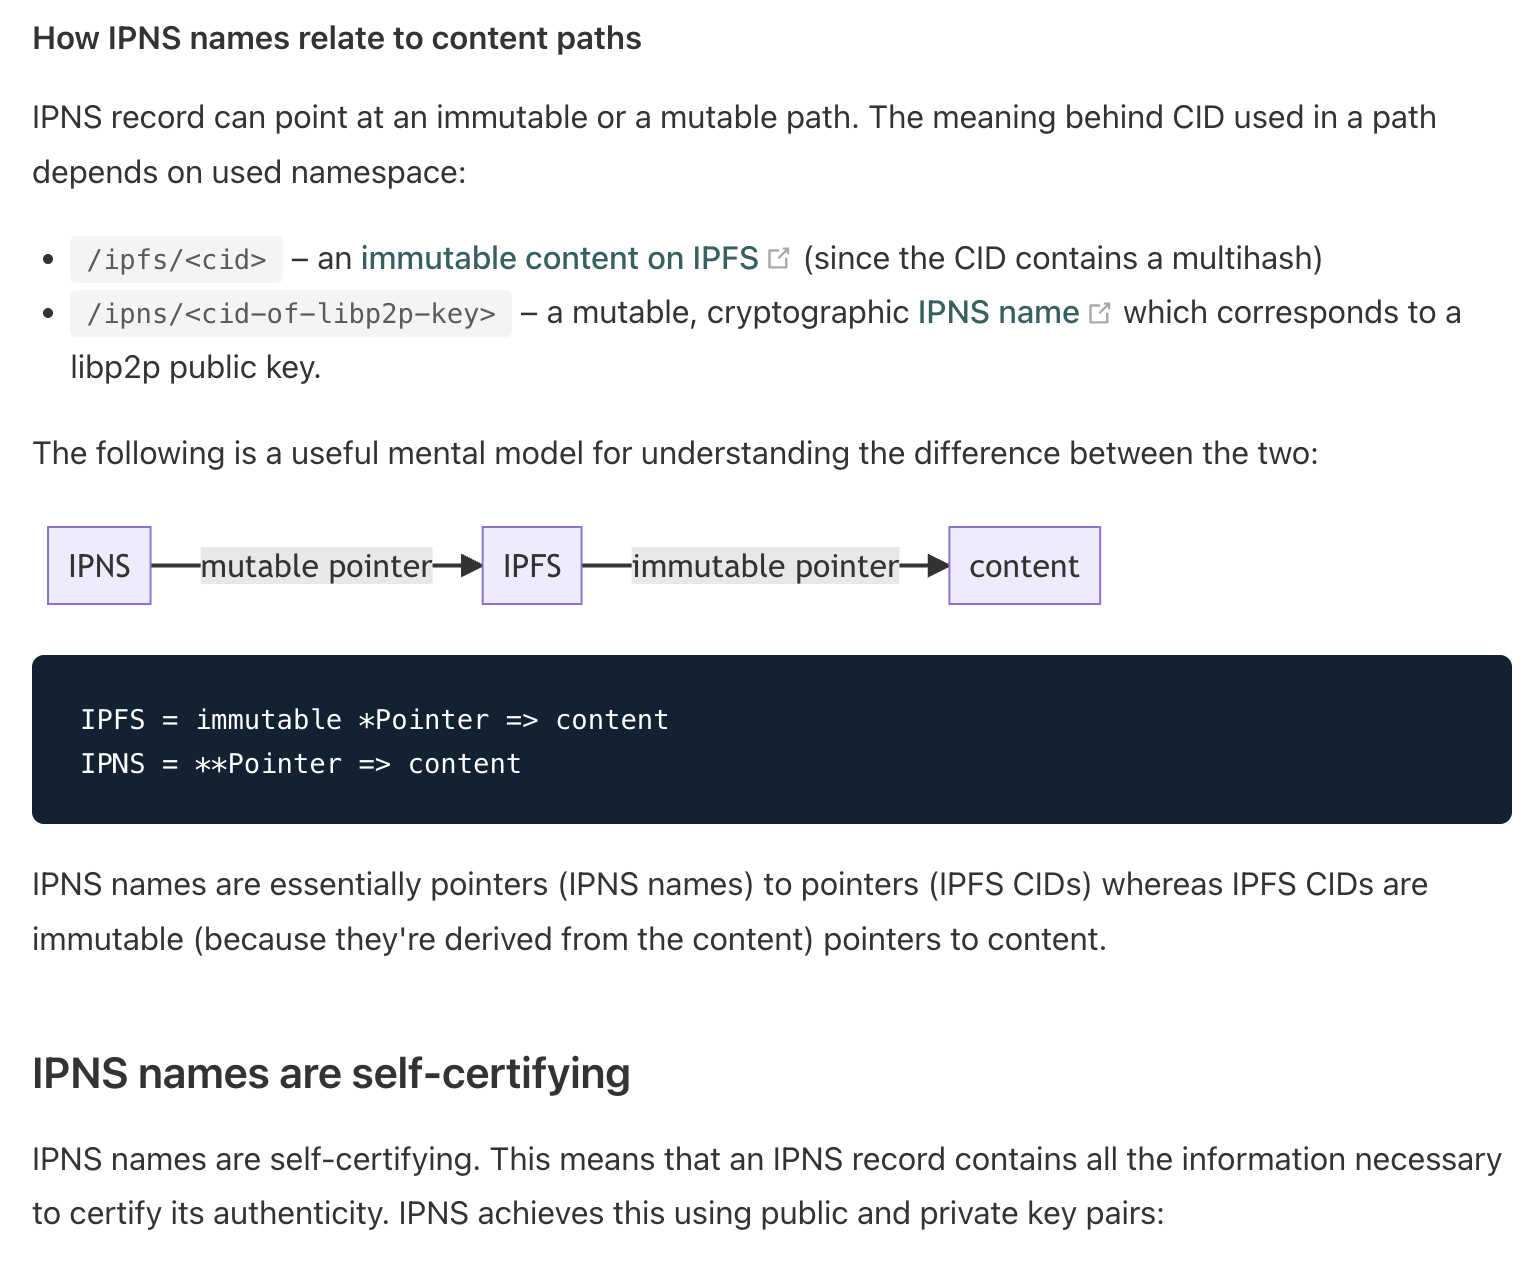

### Zarr

[Zarr](https://zarr.readthedocs.io/en/stable/getting_started.html) is an open source cloud optimized data specification for storing n-dimensional. Data is split into parts called chunks along some dimension, the chunks have incremental values (e.g 0.1.0 - a value for each dimension) which is then associated to the bytes for that chunk, and then stored in a key/value data manifest. This means that n-dimensional data such as gridded raster data can be stored and read without requiring the need for a traditional running server which calculates these chunks per request. You may already be familiar with [NetCDF](https://en.wikipedia.org/wiki/NetCDF), GRIB, GeoTIFF - Zarr serves as a way to provide similar functionality with reduced server overhead. Learn more about Analysis Ready Cloud Optimized datasets here: https://blog.lobelia.earth/arco-the-smartest-way-to-access-big-geospatial-data-eaf689eff3c9 

### How do you access Zarr data on IPFS?

Using the [py-hamt](https://github.com/dClimate/py-hamt) library developed by [dClimate](https://www.dclimate.net/) you are able to read zarr datasets directly from IPFS via traditional data analysis tools such as [xarray](https://docs.xarray.dev/en/stable/). Py-hamt leverages concepts such as [IPLD](https://ipld.io/) and [HAMT](https://ipld.io/specs/advanced-data-layouts/hamt/spec/#summary) in order to serve data in a seamless and distributed fashion directly from IPFS with no strings attached. Just use the hashes we provide as examples to read datasets or learn how to create your own by onboarding data into the decentralized ecosystem by visiting the example [Creating an ETL - CPC](./Creating%20an%20ETL%20-%20CPC.ipynb)


# What is this notebook? 

This [Jupyter notebook](https://jupyter.org/) has IPFS loaded on the same container* whether it is deployed via [Github Codespaces](https://github.com/codespaces), locally with [Docker](https://en.wikipedia.org/wiki/Docker_(software)), or deployed on a platform such as [Railway](https://railway.com/). 

* "A container is a standard unit of software that packages up code and all its dependencies so the application runs quickly and reliably from one computing environment to another. A Docker container image is a lightweight, standalone, executable package of software that includes everything needed to run an application: code, runtime, system tools, system libraries and settings." - https://www.docker.com/resources/what-container/#:~:text=A%20Docker%20container%20image%20is,tools%2C%20system%20libraries%20and%20settings. 

A notebook makes it easy to run code without needing to create/run scripts manually and when combined with containers, everything is self contained so you don't have to worry about configuring environments, using conda, or wondering why your computer is now broken. Things "just work". With IPFS already installed and running on the container, you are directly able to access the decentralized network of data without doing anything special. 

A brief explanation of the directory structure:

```
- /downloaded_data (Where any raw data such as binary file types are downloaded to be processed into zarrs)
  - /gis
  - /bio 
- /processed_data (Where intemediary processed data goes if necessary, usually only necessary for the bio files)
  - /gis
  - /bio
- /output_data (Where output zarrs ready to be loaded onto ipfs live alongside any other output files)
  - /gis
  - /bio
- Bioinformatics.ipynb (A beginner notebook showing how Zarrs can be read from and written to IPFS similar to GIS )
- Creating an ETL - CPC.ipynb (A beginner notebook to learn how to write GIS data to IPFS) 
- Getting Started.ipynb (The notebook you are reading which gives an introduction to the concepts and infrastructure)
```

## How do you run this notebook?

You have a few options:

- Running locally:
    - First pull down this repo to your machine by tapping the green `Code` button and clone using your preferred method of choice, whether HTTPS, SSH, or downloading a zip. If you download a zip make sure you unzip the file into a folder you can navigate to.
    - Ensure you first have docker installed. If you do not, head over to https://www.docker.com/ and install docker (it's free!). Ensure the docker daemon is running by opening the application and following any instructions to start the daemon if necessary. 
    - Open your terminal and navigate to root directory of the repo you just downloaded, where you should see a `docker-compose.yml` file if you run `ls`. From the same directory just run `docker compose up` and in your terminal you should see some logs such as IPFS (Kubo) starting alongside the Jupyter notebook. You should then be able to access the notebook by visiting http://127.0.0.1:8888 in your browser using the key set within the `docker-compose.yml` file. The default is set to `your_secure_token`. Running via Docker ensures you don't have to worry about conda environments, your python version, package managers etc. To simply install another package make sure to use `uv` by using `!uv pip install`.
- Github Codespaces: If you found this repo on github you can simply go over to the Github repo over at https://github.com/dClimate/jupyter-notebooks tap `Code` -> `Codespaces` -> `+ (Create Codespace)`. This will bring you to a page which takes up to a minute to load but you can interact with the deployed container either through an in browser editor or connect your local VSCode to the Jupyter notebook running on Github. Note: Github provides a certain amount of free minutes before they begin to charge
- Deploying on Railway. Railway is a PaaS (Platform as a Service) tool similar to heroku which makes launching apps a breeze. As long as you have an account you can deploy applications using templates without any configuration. What's more is that if your costs remain below $5 a month (which the IPFS notebook does) it remains free! You can find the template to deploy [here](https://railway.com/template/oaqTcv?referralCode=1CR-cB). Tap deploy now to get started. Once the deployment has finished and you see a green checkmark visit the URL listed under "deployments", it should be a "****.railway.app" url. If you get an error, wait 30 seconds and refresh. Then use the secure token you set when you deployed the template to login.
- Deploying elsewhere. The repo comes with a `docker-compose.yml` which is what's used to run the application locally. The same docker-compose can be used to deploy remotely. We will soon have [Pulumi](https://github.com/pulumi/pulumi) scripts to have CLI deploys onto other cloud services, especially those that charge zero 

Without further ado, let's get into it!

We check the version of IPFS below as we need to ensure we are running on the correct version which is > 3.12. If you are running this in a Github Codespace or in VSCode ensure that the right Python Kernel is selected which should be the .venv path directory of the current project. 

In [1]:
!python --version

Python 3.12.7


We check the running version of ipfs, as of creating this notebook the latest version was 0.32.1 which works well :)

In [2]:
!ipfs --version

ipfs version 0.33.2


Below we use [uv](https://docs.astral.sh/uv/) instead of pip alone to install python packages as it's much faster, more performant and has automatic lockfiles so you never have to worry about playing around with versions in a requirements.txt file. Feel free to use pip in your own projects but we've found uv to be a lifesaver and works quite well with this repo

In [3]:
!uv pip install xarray zarr multiformats git+https://github.com/dClimate/py-hamt.git

Using Python 3.12.7 environment at: /opt/venv
Resolved 37 packages in 2.30s                                        
Prepared 1 package in 4.16s                                              
Uninstalled 1 package in 6ms
░░░░░░░░░░░░░░░░░░░░ [0/1] Installing wheels...                                 warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 2msm git+https://github.com/dClimate/
 - py-hamt==2.4.0 (from git+https://github.com/dClimate/py-hamt.git@3ac5d99d537b4727480ff388f91d2dc0e7b9a58b)
 + py-hamt==2.4.1 (from git+https://github.com/dClimate/py-hamt.git@5829bb13fc08d456a0f6b16e193b3d048c1b2977)


Below we use the ipfs cli tool to add the 3 dClimate nodes which are hosting GIS data. Feel free to add more nodes here if you are aware of any other nodes hosting data you want to pull from. The currently most updated list of node addresses can be found on the dClimate developer documentation.

In [3]:
# Fluorine Node
!ipfs swarm peering add "/ip4/15.235.14.184/udp/4001/quic-v1/p2p/12D3KooWHdZM98wcuyGorE184exFrPEJWv2btXWWSHLQaqwZXuPe"

# Cerium Node
!ipfs swarm peering add "/ip4/15.235.86.198/udp/4001/quic-v1/p2p/12D3KooWGX5HDDjbdiJL2QYf2f7Kjp1Bj6QAXR5vFvLQniTKwoBR"

# Bismuth Node
!ipfs swarm peering add "/ip4/40.160.21.102/udp/4001/quic-v1/p2p/12D3KooWEaVCpKd2MgZeLugvwCWRSQAMYWdu6wNG6SySQsgox8k5"

add 12D3KooWHdZM98wcuyGorE184exFrPEJWv2btXWWSHLQaqwZXuPe success
add 12D3KooWGX5HDDjbdiJL2QYf2f7Kjp1Bj6QAXR5vFvLQniTKwoBR success
add 12D3KooWEaVCpKd2MgZeLugvwCWRSQAMYWdu6wNG6SySQsgox8k5 success


**Sidequest**: If you are curious about what the node address is of the IPFS node running alongside the Jupyter notebook, run the command below. You will see all the different addresses. Depending on how you are looking to connect to this node you can provide the `tcp` address of this node to your friends in the same pattern as above, if they are connecting via another notebook or if they are looking to connect from a browser with [Helia](https://github.com/ipfs/helia) you can provide the `webrtc-direct` address. If you run this from railway you'll see a url within the Announce array which will be the address given to the wider IPFS network so that other nodes can connect to you via websockets.

In [26]:
!ipfs config Addresses

{
  "API": "/ip4/127.0.0.1/tcp/5001",
  "Announce": [],
  "AppendAnnounce": [],
  "Gateway": "/ip4/0.0.0.0/tcp/8080",
  "NoAnnounce": [],
  "Swarm": [
    "/ip4/0.0.0.0/tcp/4001",
    "/ip6/::/tcp/4001",
    "/ip4/0.0.0.0/udp/4001/webrtc-direct",
    "/ip4/0.0.0.0/udp/4001/quic-v1",
    "/ip4/0.0.0.0/udp/4001/quic-v1/webtransport",
    "/ip6/::/udp/4001/webrtc-direct",
    "/ip6/::/udp/4001/quic-v1",
    "/ip6/::/udp/4001/quic-v1/webtransport",
    "/ip4/0.0.0.0/tcp/4001/ws",
    "/ip6/::/tcp/4001/ws"
  ]
}


## dClimate Catalog

As mentioned in the IPNS section above, dClimate publishes all the CIDs to its latest datasets on the fixed IPNS CID below. This CID can be resolved to get the latest corresponding CIDs for each dataset.

In [1]:
dclimate_catalog_cid = !ipfs name resolve /ipns/k51qzi5uqu5dk89atnl883sr0g1cb2py631ckz9ng45qhk6dg0pj141jtxtx6l
print(dclimate_catalog_cid)

['/ipfs/z4EBG9j5dMe4BAsKBXHuV5zE6BNWAhUnDyCMhukLLNDsq2f9rL2']


Print the contents of the root of the dClimate catalog

In [5]:
dclimate_static_resolve_cid = dclimate_catalog_cid[0]
!ipfs dag get {dclimate_static_resolve_cid} | python -m json.tool

{
    "description": "This catalog contains dClimate's data.",
    "id": "dClimate-data-catalog",
    "links": [
        {
            "href": "/ipfs/z4EBG9jChCbDtxjHbBpzc2qNjPwrbsua5wVyztX4d4n3PuhfLGM",
            "rel": "child",
            "title": "CPC",
            "type": "application/json"
        },
        {
            "href": "/ipfs/z4EBG9jCuqRaMCJ5uUeECDmJoZnAujewzBLBuHhnivvZarCYmNn",
            "rel": "child",
            "title": "CHIRPS",
            "type": "application/json"
        },
        {
            "href": "/ipfs/z4EBG9j7EJQZgqdQHjxuVpuLp7RjiCtiHogbvsFBhqm9VMGPrya",
            "rel": "child",
            "title": "ERA5",
            "type": "application/json"
        }
    ],
    "stac_version": "1.0.0",
    "type": "Catalog"
}


Inspect one of the datasets in this catalog by taking the cid of the CPC catalog via

In [24]:
import json

# Get the catalog as a list of lines
catalog_lines = !ipfs dag get {dclimate_static_resolve_cid}

# Join the lines into a single JSON string
catalog_str = "".join(catalog_lines)

# Parse the JSON string into a dictionary
catalog_dict = json.loads(catalog_str)

# Find the link with the title "CPC"
cpc_link = next((link for link in catalog_dict["links"] if link["title"] == "CPC"), None)

if cpc_link:
    # Remove the '/ipfs/' prefix to get the CID
    cid = cpc_link["href"].split("/ipfs/")[-1]
    print("CID for CPC:", cid)
    print("STAC for CPC dataset:")
    !ipfs dag get {cid} | python -m json.tool
    
else:
    print("CPC link not found.")


CID for CPC: z4EBG9jChCbDtxjHbBpzc2qNjPwrbsua5wVyztX4d4n3PuhfLGM
STAC for CPC dataset:
{
    "description": "",
    "extent": {
        "spatial": {
            "bbox": [
                [
                    -180,
                    90,
                    180,
                    90
                ]
            ]
        },
        "temporal": {
            "interval": [
                [
                    "1979-01-01T00:00:00Z",
                    "null"
                ]
            ]
        }
    },
    "id": "CPC",
    "license": "noassertion",
    "links": [
        {
            "href": "/ipfs/z4EBG9j5qhz5k7N1XsZ9qD8hPfdpkcaXYeHxTwtrkGBCgZwpYsF",
            "rel": "item",
            "title": "cpc-precip-conus",
            "type": "application/json"
        },
        {
            "href": "/ipfs/z4EBG9jA3kvnFaA3L7KUrLZyaJ2oXQMkZjTAqMnPqrUrfDvgspi",
            "rel": "item",
            "title": "cpc-precip-global",
            "type": "application/json"
        },
   

Print out the dClimate Catalog dataset names along with their corresponding CIDs.

In [8]:
import json
from pprint import pprint

def read_from_ipfs(cid: str) -> dict:
    # Use the Jupyter notebook shell command to get the IPFS content.
    # The output is a list of strings; join them to form a valid JSON string.
    ipfs_output = !ipfs dag get {cid}
    ipfs_str = "".join(ipfs_output)
    return json.loads(ipfs_str)

# Replace this with your catalog CID; you might have resolved it via !ipfs name resolve.
catalog_cid = dclimate_static_resolve_cid
catalog = read_from_ipfs(catalog_cid)
catalog_json_out = {catalog["id"]: catalog_cid}

collections = []
collections_json_out = {}
for link in catalog.get("links", []):
    # Remove the /ipfs/ prefix from the href.
    cid = link["href"][6:]
    collection = read_from_ipfs(cid)
    collections_json_out[collection["id"]] = cid
    collections.append(collection)

items_json_out = {}
for collection in collections:
    for link in collection.get("links", []):
        cid = link["href"][6:]
        item = read_from_ipfs(cid)
        items_json_out[item["id"]] = cid

# Determine the output type. Avoid using the built-in name 'type' by using 'type_requested'.
type_requested = "all"  # Options: "all", "collection", "item"

if type_requested == "all":
    # Merge dictionaries using the unpacking operator (Python 3.9+)
    json_out = {**catalog_json_out, **collections_json_out, **items_json_out}
elif type_requested == "collection":
    json_out = collections_json_out
elif type_requested == "item":
    json_out = items_json_out
else:
    json_out = {}

# Print the result.
# If you prefer a plain print, you could iterate over the dict; here we pretty print it.
pprint(json_out)


{'CHIRPS': 'z4EBG9jCuqRaMCJ5uUeECDmJoZnAujewzBLBuHhnivvZarCYmNn',
 'CPC': 'z4EBG9jChCbDtxjHbBpzc2qNjPwrbsua5wVyztX4d4n3PuhfLGM',
 'ERA5': 'z4EBG9j7EJQZgqdQHjxuVpuLp7RjiCtiHogbvsFBhqm9VMGPrya',
 'chirps-final-p05': 'z4EBG9jGWMfTMKMGiQtdb3ffd66QCreWUdd17nkyPzrhWam2Zf3',
 'chirps-final-p25': 'z4EBG9j6LnQa83jxLyVUytvXZqsthkjooKnBfjQxJseKR1aeTe2',
 'chirps-prelim-p05': 'z4EBG9jCLWU7SQa7CcSSW2vpJoy3TjkRCcXcrQ3MuFESLwPB63y',
 'cpc-precip-conus': 'z4EBG9j5qhz5k7N1XsZ9qD8hPfdpkcaXYeHxTwtrkGBCgZwpYsF',
 'cpc-precip-global': 'z4EBG9jA3kvnFaA3L7KUrLZyaJ2oXQMkZjTAqMnPqrUrfDvgspi',
 'cpc-tmax': 'z4EBG9jDAgkSdL1ptCZs5hxCRQB5hE5SYvSqkshwbws7P32yPWy',
 'cpc-tmin': 'z4EBG9j6wxMeYvZGGk1Bb8tErLkQJvCv8oPUBMgcBAiNBsRw8R5',
 'dClimate-data-catalog': '/ipfs/z4EBG9j5dMe4BAsKBXHuV5zE6BNWAhUnDyCMhukLLNDsq2f9rL2',
 'era5-10m_u_component_of_wind': 'z4EBG9j9yewLFTHDSFi2EF5HX17P9eMyHpMVKCYBJqSyVXPf6nH',
 'era5-2m_temperature': 'z4EBG9j4AHzSXY1qgw7NKBbED39P8HC3RqrPBgoDaLRGN7NN8VJ'}


In [10]:
!ipfs dag get z4EBG9j5qhz5k7N1XsZ9qD8hPfdpkcaXYeHxTwtrkGBCgZwpYsF | python -m json.tool


{
    "assets": {
        "hamt-zarr": {
            "href": "/ipfs/bafyr4ibydqb3ce5a42yzbuuxnhmglp6byse4e7osc6p3nrxiiebriqdx7a"
        }
    },
    "bbox": [
        "-129.875",
        "20.125",
        "-55.125",
        "49.875"
    ],
    "geometry": "{'type': 'Polygon', 'coordinates': [[['-55.125', '20.125'], ['-55.125', '49.875'], ['-129.875', '49.875'], ['-129.875', '20.125'], ['-55.125', '20.125']]]}",
    "id": "cpc-precip-conus",
    "links": [],
    "properties": {
        "datetime": "null",
        "end_datetime": "2025-04-08T00:00:00Z",
        "start_datetime": "2007-01-01T00:00:00Z"
    },
    "stac_version": "1.0.0",
    "type": "Feature"
}


Let's take the CID of the cpc-precip-conus and store it in a varialble in order to query the data. We are gettng the root of the hamt for the zarr stored on IPFS.

In [12]:
cpc_precip_conus_catalog_cid = !ipfs dag get z4EBG9j5qhz5k7N1XsZ9qD8hPfdpkcaXYeHxTwtrkGBCgZwpYsF | python -m json.tool

In [13]:
# Parse the JSON string into a Python dictionary
json_str = "".join(cpc_precip_conus_catalog_cid)
item = json.loads(json_str)

# Access the href from the asset "hamt-zarr"
href = item["assets"]["hamt-zarr"]["href"]

# Remove the '/ipfs/' prefix to get the CID. Using split works universally:
cpc_precip_conus_cid = href.split("/ipfs/")[-1]

print("CID:", cpc_precip_conus_cid)

CID: bafyr4ibydqb3ce5a42yzbuuxnhmglp6byse4e7osc6p3nrxiiebriqdx7a


# Reading the Data

In the code below we use the `py_hamt` library to load a dataset into xarray to run some rudimentary analysis to demonstrate that you can do all the things you are accustomed to in GIS, instead with decentralized data. Note: we have hashes for each dataset and we will be adding more for each additional dataset we add. If you wish to switch the dataset, just swap the hash for the dataset_cid using the method above. You can 

In [14]:
import xarray as xr
from py_hamt import HAMT, IPFSStore, IPFSZarr3
from multiformats import CID

# Root CID of the HAMT
dataset_cid = cpc_precip_conus_cid

# Convert the string to a CID Object Type
root_cid = CID.decode(dataset_cid)

# Create HAMT instance using the IPFSStore connecting to your locally running IPFS Gateway from your local running IPFS Node
hamt = HAMT(store=IPFSStore(gateway_uri_stem="http://0.0.0.0:8080"), root_node_id=root_cid)

# Load the HAMT as a ZarrV3
ipfszarr3 = IPFSZarr3(hamt, read_only=True)

# You can instead try running 

ds = xr.open_zarr(store=ipfszarr3)
ds

<xarray.Dataset> Size: 961MB
Dimensions:    (time: 6673, latitude: 120, longitude: 300)
Coordinates:
  * time       (time) datetime64[ns] 53kB 2007-01-01 2007-01-02 ... 2025-04-08
  * longitude  (longitude) float32 1kB -129.9 -129.6 -129.4 ... -55.38 -55.12
  * latitude   (latitude) float32 480B 20.12 20.38 20.62 ... 49.38 49.62 49.88
Data variables:
    precip     (time, latitude, longitude) float32 961MB dask.array<chunksize=(400, 25, 25), meta=np.ndarray>
Attributes:
    title:          CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    Conventions:    COARDS
    history:        created 04/2010 by CAS from data obtained from NCEP/CPC\n...
    description:    Gridded daily Precipitation
    platform:       Observations
    Comments:       Preciptation is accumulated from 12z of previous day to 1...
    dataset_title:  CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    References:     http://www.psl.noaa.gov/data/gridded/data.unified.daily.c...

**Note**: the values for both latitude and longitude are positive.

In [15]:
print(ds.latitude.values)

[20.125 20.375 20.625 20.875 21.125 21.375 21.625 21.875 22.125 22.375
 22.625 22.875 23.125 23.375 23.625 23.875 24.125 24.375 24.625 24.875
 25.125 25.375 25.625 25.875 26.125 26.375 26.625 26.875 27.125 27.375
 27.625 27.875 28.125 28.375 28.625 28.875 29.125 29.375 29.625 29.875
 30.125 30.375 30.625 30.875 31.125 31.375 31.625 31.875 32.125 32.375
 32.625 32.875 33.125 33.375 33.625 33.875 34.125 34.375 34.625 34.875
 35.125 35.375 35.625 35.875 36.125 36.375 36.625 36.875 37.125 37.375
 37.625 37.875 38.125 38.375 38.625 38.875 39.125 39.375 39.625 39.875
 40.125 40.375 40.625 40.875 41.125 41.375 41.625 41.875 42.125 42.375
 42.625 42.875 43.125 43.375 43.625 43.875 44.125 44.375 44.625 44.875
 45.125 45.375 45.625 45.875 46.125 46.375 46.625 46.875 47.125 47.375
 47.625 47.875 48.125 48.375 48.625 48.875 49.125 49.375 49.625 49.875]


In [16]:
print(ds.longitude.values)

[-129.875 -129.625 -129.375 -129.125 -128.875 -128.625 -128.375 -128.125
 -127.875 -127.625 -127.375 -127.125 -126.875 -126.625 -126.375 -126.125
 -125.875 -125.625 -125.375 -125.125 -124.875 -124.625 -124.375 -124.125
 -123.875 -123.625 -123.375 -123.125 -122.875 -122.625 -122.375 -122.125
 -121.875 -121.625 -121.375 -121.125 -120.875 -120.625 -120.375 -120.125
 -119.875 -119.625 -119.375 -119.125 -118.875 -118.625 -118.375 -118.125
 -117.875 -117.625 -117.375 -117.125 -116.875 -116.625 -116.375 -116.125
 -115.875 -115.625 -115.375 -115.125 -114.875 -114.625 -114.375 -114.125
 -113.875 -113.625 -113.375 -113.125 -112.875 -112.625 -112.375 -112.125
 -111.875 -111.625 -111.375 -111.125 -110.875 -110.625 -110.375 -110.125
 -109.875 -109.625 -109.375 -109.125 -108.875 -108.625 -108.375 -108.125
 -107.875 -107.625 -107.375 -107.125 -106.875 -106.625 -106.375 -106.125
 -105.875 -105.625 -105.375 -105.125 -104.875 -104.625 -104.375 -104.125
 -103.875 -103.625 -103.375 -103.125 -102.875 -102.

In [134]:
!uv pip install matplotlib pandas seaborn cartopy

Using Python 3.12.7 environment at: /opt/venv
Audited 4 packages in 38ms


In [17]:
# Define geographic bounding box (e.g., USA region)
lat_min, lat_max = 25, 50  # Latitude range
lon_min, lon_max = -130, -60  # Longitude range

# Define time range
start_date = "2020-01-01"
end_date = "2020-12-31"

# Subset the data
subset = ds.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max),
    time=slice(start_date, end_date)
)

# Trigger computation (e.g., convert to numpy or pandas if needed)
precip_data = subset["precip"].compute()

# Compute monthly means
monthly_precip = subset["precip"].groupby("time.month").mean(dim="time")

# Compute spatial averages
spatial_mean = subset["precip"].mean(dim=["latitude", "longitude"])

print(monthly_precip)
print(spatial_mean)


<xarray.DataArray 'precip' (month: 12, latitude: 100, longitude: 280)> Size: 1MB
dask.array<stack, shape=(12, 100, 280), dtype=float32, chunksize=(1, 25, 25), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 1kB -129.9 -129.6 -129.4 ... -60.38 -60.12
  * latitude   (latitude) float32 400B 25.12 25.38 25.62 ... 49.38 49.62 49.88
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:     Daily Accumulated Precipitation
    valid_range:   [0.0, 700.0]
    units:         mm
    precision:     2
    var_desc:      Precipitation
    dataset:       CPC Unified Gauge-Based Analysis of Daily Precipitation ov...
    level_desc:    Surface
    statistic:     Daily Accumulation
    parent_stat:   Observation
    actual_range:  [0.0, 273.43914794921875]
<xarray.DataArray 'precip' (time: 366)> Size: 1kB
dask.array<mean_agg-aggregate, shape=(366,), dtype=float32, chunksize=(314,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetim

## Plotting Data

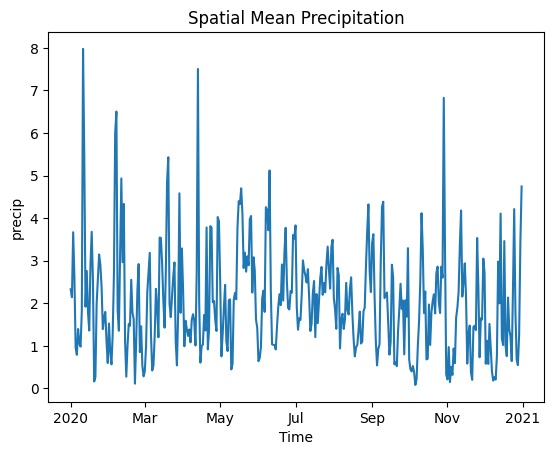

In [18]:
import matplotlib.pyplot as plt

# Plot the spatial mean precipitation over time
spatial_mean.plot()
plt.title("Spatial Mean Precipitation")
plt.show()

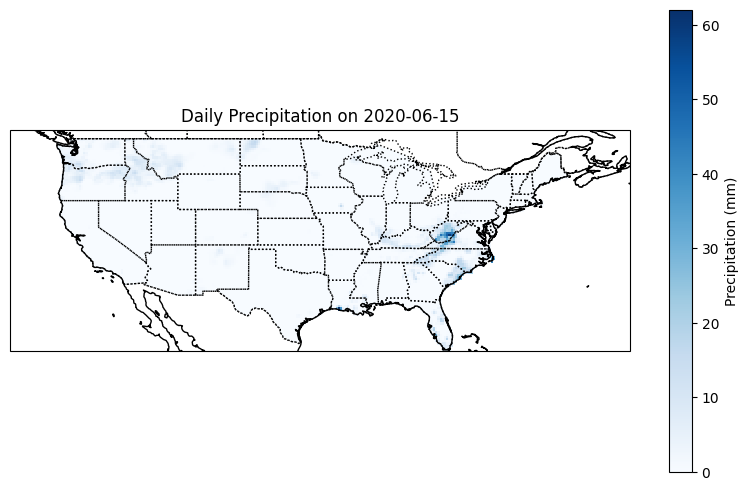

In [19]:
# Visualizing Spatial Data (Map)
# To plot precipitation over a geographic area for a specific day or averaged over a time range:

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Plot precipitation for a specific day
specific_day = subset.sel(time="2020-06-15")  # Choose a date

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
precip = specific_day["precip"].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    cbar_kwargs={"label": "Precipitation (mm)"}
)
ax.set_title("Daily Precipitation on 2020-06-15")
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.STATES, linestyle=":")
plt.show()

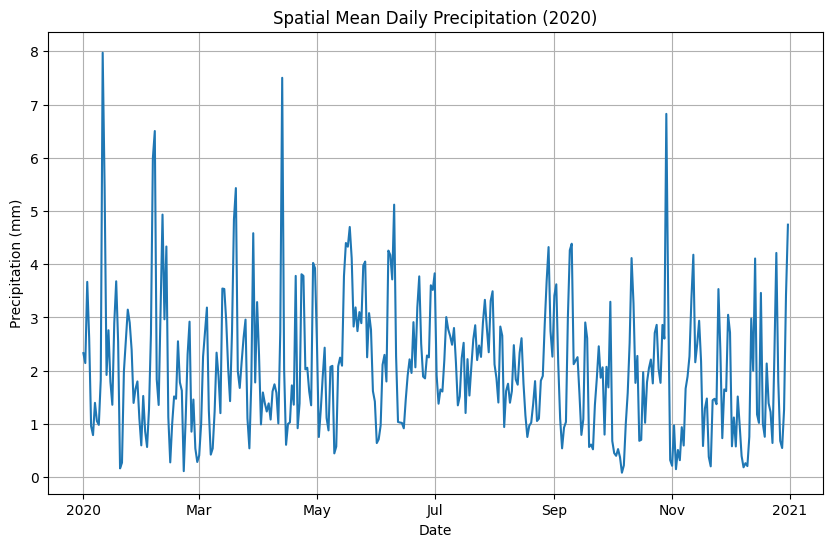

In [20]:
# Time Series Plot
# Calculate spatial mean precipitation
spatial_mean = subset["precip"].mean(dim=["latitude", "longitude"])

plt.figure(figsize=(10, 6))
spatial_mean.plot()
plt.title("Spatial Mean Daily Precipitation (2020)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.grid()
plt.show()

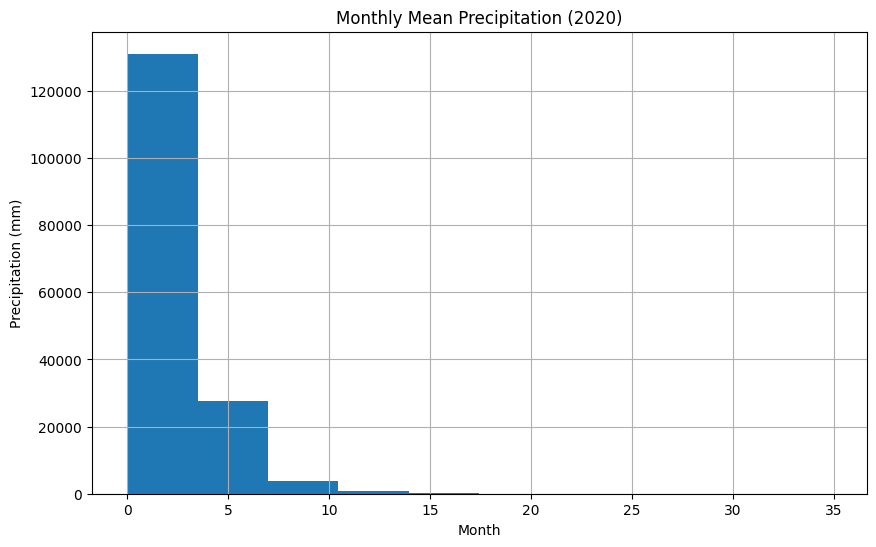

In [139]:
# Monthly Average Precipitation
# To visualize seasonal trends:

# Compute monthly means
monthly_mean = subset["precip"].groupby("time.month").mean(dim="time")

plt.figure(figsize=(10, 6))
monthly_mean.plot()
plt.title("Monthly Mean Precipitation (2020)")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.grid()
plt.show()

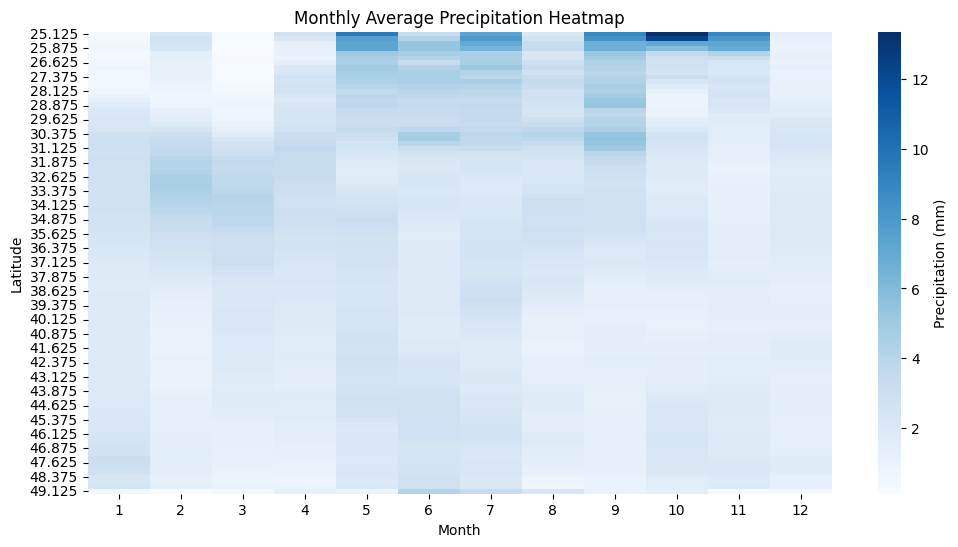

In [21]:
# Spatial Aggregation and Heatmap
# To show aggregated precipitation over time as a heatmap:

import seaborn as sns
import pandas as pd

# Aggregate data (e.g., by month and location)
monthly_precip = subset["precip"].groupby("time.month").mean(dim="time")
monthly_df = monthly_precip.mean(dim=["longitude"]).to_dataframe()

# Plot as a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    monthly_df.pivot_table(index="latitude", columns="month", values="precip"),
    cmap="Blues",
    cbar_kws={"label": "Precipitation (mm)"}
)
plt.title("Monthly Average Precipitation Heatmap")
plt.xlabel("Month")
plt.ylabel("Latitude")
plt.show()

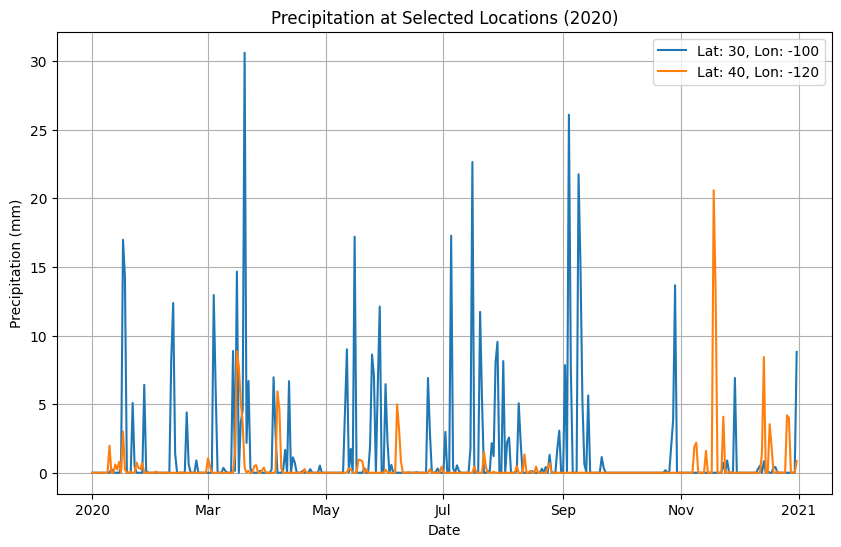

In [22]:
# Comparing Locations
# To plot precipitation for multiple locations over time:

# Select specific locations
locations = [(30, -100), (40, -120)]  # (latitude, longitude) pairs

plt.figure(figsize=(10, 6))
for lat, lon in locations:
    location_precip = subset.sel(latitude=lat, longitude=lon, method="nearest")["precip"]
    location_precip.plot(label=f"Lat: {lat}, Lon: {lon}")

plt.title("Precipitation at Selected Locations (2020)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.legend()
plt.grid()
plt.show()

## Making an Animated gif

If you're reading this on github, it doesn't embed the image in the notebook so you must look in the file directory output as the below outputs a file named `precipitation_animation.gif`.

Subset info:
<xarray.Dataset> Size: 1MB
Dimensions:    (time: 11, latitude: 100, longitude: 280)
Coordinates:
  * time       (time) datetime64[ns] 88B 2020-06-10 2020-06-11 ... 2020-06-20
  * longitude  (longitude) float32 1kB -129.9 -129.6 -129.4 ... -60.38 -60.12
  * latitude   (latitude) float32 400B 25.12 25.38 25.62 ... 49.38 49.62 49.88
Data variables:
    precip     (time, latitude, longitude) float32 1MB dask.array<chunksize=(11, 5, 25), meta=np.ndarray>
Attributes:
    title:          CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    Conventions:    COARDS
    history:        created 04/2010 by CAS from data obtained from NCEP/CPC\n...
    description:    Gridded daily Precipitation
    platform:       Observations
    Comments:       Preciptation is accumulated from 12z of previous day to 1...
    dataset_title:  CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    References:     http://www.psl.noaa.gov/data/gridded/data.unified.daily.c...
Animatio

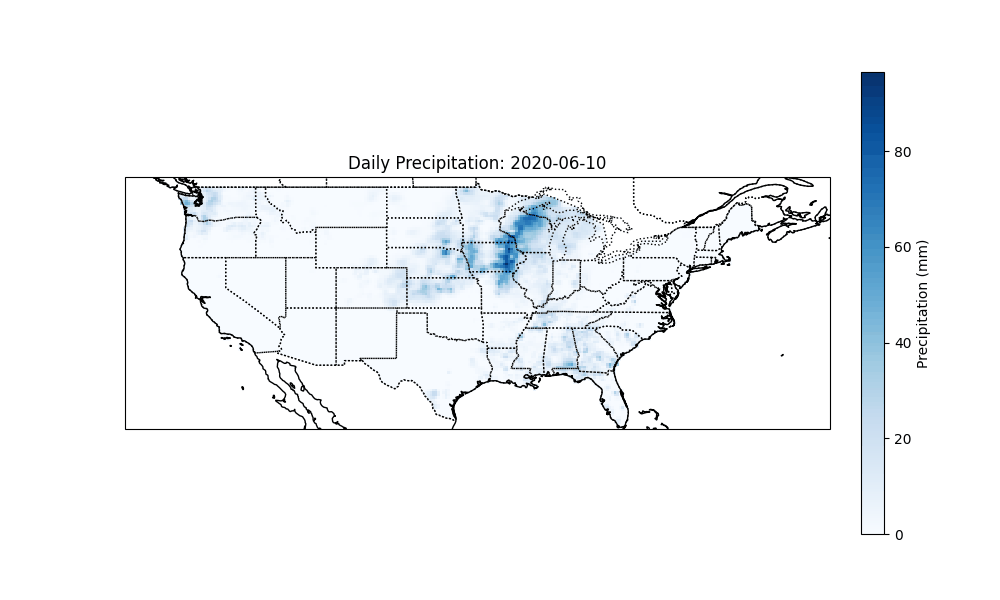

In [23]:
# Create animated GIF

import matplotlib.animation as animation

# Define bounding box and time range
lat_min, lat_max = 25, 50  # Latitude range
lon_min, lon_max = -130, -60  # Longitude range
start_date = "2020-06-10"
end_date = "2020-06-20"

# Subset the data
subset = ds.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max),
    time=slice(start_date, end_date)
)
print("Subset info:")
print(subset)

# Set up the figure and axis for animation
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# Add a single colorbar outside the update function
cbar = None  # Global colorbar reference

def update(frame):
    """Update function for each frame."""
    global cbar  # Refer to the global colorbar

    ax.clear()
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.STATES, linestyle=":")

    # Extract precipitation data for the current day
    day_precip = subset.isel(time=frame)["precip"]

    # Plot the precipitation
    precip_plot = day_precip.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="Blues",
        add_colorbar=False  # Prevent automatic addition of a colorbar
    )

    # Add a single colorbar if it hasn't been created
    if cbar is None:
        cbar = fig.colorbar(precip_plot, ax=ax, orientation="vertical", fraction=0.05, pad=0.04)
        cbar.set_label("Precipitation (mm)")

    # Set dynamic title with the current date
    ax.set_title(f"Daily Precipitation: {str(day_precip.time.values)[:10]}")

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=len(subset.time), interval=500)

# Save the animation as a GIF
ani.save("precipitation_animation.gif", writer="pillow")
print("Animation saved as 'precipitation_animation.gif'.")

# Close the figure to prevent the static plot from being displayed
plt.close(fig)

from IPython.display import Image, display

# Display the generated GIF
display(Image(filename="precipitation_animation.gif"))

# Optionally display the animation (useful for notebooks)
# plt.show()
